<a href="https://colab.research.google.com/github/nguyentrongnguyen3004-eng/DeepLearning_Chest_X_Ray/blob/main/CNN_thu%E1%BA%A7n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [2]:
import os

# Đường dẫn đến thư mục chứa dữ liệu chính đã được hiển thị trong hình của bạn
base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'

# Danh sách các thư mục cần đếm
folders = ['train', 'test', 'val']

print("=== THỐNG KÊ SỐ LƯỢNG ẢNH ===")

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    print(f"\nThư mục: {folder}")

    total_images_in_folder = 0

    # Kiểm tra xem thư mục có tồn tại không
    if os.path.exists(folder_path):
        # Lấy danh sách các thư mục con (các nhãn/class)
        classes = os.listdir(folder_path)

        for class_name in classes:
            class_path = os.path.join(folder_path, class_name)

            # Chỉ đếm trong các thư mục hợp lệ (bỏ qua file rác hoặc __MACOSX nếu có)
            if os.path.isdir(class_path) and not class_name.startswith('.'):
                # Đếm số file trong thư mục class này
                num_images = len(os.listdir(class_path))
                print(f"  - Lớp '{class_name}': {num_images} ảnh")
                total_images_in_folder += num_images

        print(f"  => Tổng cộng tập {folder}: {total_images_in_folder} ảnh")
    else:
        print("  Không tìm thấy thư mục này.")

=== THỐNG KÊ SỐ LƯỢNG ẢNH ===

Thư mục: train
  - Lớp 'PNEUMONIA': 3875 ảnh
  - Lớp 'NORMAL': 1341 ảnh
  => Tổng cộng tập train: 5216 ảnh

Thư mục: test
  - Lớp 'PNEUMONIA': 390 ảnh
  - Lớp 'NORMAL': 234 ảnh
  => Tổng cộng tập test: 624 ảnh

Thư mục: val
  - Lớp 'PNEUMONIA': 8 ảnh
  - Lớp 'NORMAL': 8 ảnh
  => Tổng cộng tập val: 16 ảnh


In [3]:

import os
import shutil
import random
import warnings
import numpy as np
import torch

warnings.filterwarnings("ignore")

# 1. Cố định Seed để đảm bảo tính tái lập (Reproducibility)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# 2. Xử lý đường dẫn động từ kagglehub
base_path = "/kaggle/input/chest-xray-pneumonia"

# Kiểm tra cấu trúc thư mục thực tế để định tuyến DATA_ROOT chính xác
if os.path.exists(os.path.join(base_path, "chest_xray", "train")):
    DATA_ROOT = os.path.join(base_path, "chest_xray")
elif os.path.exists(os.path.join(base_path, "train")):
    DATA_ROOT = base_path
else:
    raise FileNotFoundError(f"❌ Không tìm thấy thư mục 'train' bên trong {base_path}. Vui lòng kiểm tra lại quá trình tải dữ liệu.")

print(f"✅ Đã xác định đường dẫn dữ liệu gốc: {DATA_ROOT}")

# Các đường dẫn lưu trữ đầu ra (nằm trên ổ đĩa có quyền ghi của Colab)
RESPLIT_ROOT = "./chest_xray_resplit"
SAVE_PATH    = "./best_model.pth"
IMAGE_SIZE   = 224
BATCH_SIZE   = 32
VAL_SPLIT    = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Đang sử dụng thiết bị tính toán: {device}")

def resplit_dataset(data_root, resplit_root, val_split=0.2, seed=42):
    random.seed(seed)
    if os.path.exists(resplit_root):
        print(f"⚠️ Thư mục '{resplit_root}' đã tồn tại. Bỏ qua bước sao chép vật lý.")
        return None

    classes = ["NORMAL", "PNEUMONIA"]
    print("\n📂 Đang tiến hành gộp và phân chia lại dữ liệu...")
    all_paths = {cls: [] for cls in classes}

    # Gộp ảnh từ Train và Val gốc
    for split in ["train", "val"]:
        for cls in classes:
            folder = os.path.join(data_root, split, cls)
            if not os.path.exists(folder): continue
            files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith((".jpeg", ".jpg", ".png"))]
            all_paths[cls].extend(files)

    # Khởi tạo thư mục đích
    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(resplit_root, split, cls), exist_ok=True)

    # Chia lại tỷ lệ (Train/Val)
    for cls in classes:
        paths = all_paths[cls]
        random.shuffle(paths)
        n_val = int(len(paths) * val_split)
        n_train = len(paths) - n_val
        split_map = {"train": paths[:n_train], "val": paths[n_train:]}

        for split_name, file_list in split_map.items():
            for src in file_list:
                dst = os.path.join(resplit_root, split_name, cls, os.path.basename(src))
                shutil.copy2(src, dst)
        print(f"   [{cls}] Train: {n_train} | Val: {n_val}")

    # Giữ nguyên tập Test để benchmark
    for cls in classes:
        src_dir = os.path.join(data_root, "test", cls)
        dst_dir = os.path.join(resplit_root, "test", cls)
        if os.path.exists(src_dir):
            for f in os.listdir(src_dir):
                if f.lower().endswith((".jpeg", ".jpg", ".png")):
                    shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, f))

    print(f"✅ Hoàn tất thiết lập tại: {resplit_root}")
    return True

# Thực thi logic
resplit_dataset(DATA_ROOT, RESPLIT_ROOT, val_split=VAL_SPLIT)

# Tính toán Class Weights phục vụ cho hàm Mất mát (Loss function)
n_normal = len(os.listdir(os.path.join(RESPLIT_ROOT, "train", "NORMAL")))
n_pneumonia = len(os.listdir(os.path.join(RESPLIT_ROOT, "train", "PNEUMONIA")))
total = n_normal + n_pneumonia

weight_normal = total / (2 * n_normal)
weight_pneumonia = total / (2 * n_pneumonia)

print(f"\n📊 Trọng số phân lớp (Class Weights):")
print(f"   NORMAL: {weight_normal:.4f} | PNEUMONIA: {weight_pneumonia:.4f}")

✅ Đã xác định đường dẫn dữ liệu gốc: /kaggle/input/chest-xray-pneumonia/chest_xray
✅ Đang sử dụng thiết bị tính toán: cuda

📂 Đang tiến hành gộp và phân chia lại dữ liệu...
   [NORMAL] Train: 1080 | Val: 269
   [PNEUMONIA] Train: 3107 | Val: 776
✅ Hoàn tất thiết lập tại: ./chest_xray_resplit

📊 Trọng số phân lớp (Class Weights):
   NORMAL: 1.9384 | PNEUMONIA: 0.6738


In [4]:

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler

# Thông số chuẩn hóa (Z-score) theo phân phối của tập ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transform cho tập Huấn luyện (Train)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Transform cho tập Kiểm định/Kiểm tra (Val/Test) - Đảm bảo tính khách quan
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Ánh xạ thư mục thành các đối tượng Dataset
train_dataset = ImageFolder(root=os.path.join(RESPLIT_ROOT, "train"), transform=train_transform)
val_dataset   = ImageFolder(root=os.path.join(RESPLIT_ROOT, "val"),   transform=val_transform)
test_dataset  = ImageFolder(root=os.path.join(RESPLIT_ROOT, "test"),  transform=val_transform)

print(f"📂 Chỉ mục phân lớp: {train_dataset.classes} tương ứng (0, 1)")
print(f"   Tập Train: {len(train_dataset)} mẫu")
print(f"   Tập Val  : {len(val_dataset)} mẫu")
print(f"   Tập Test : {len(test_dataset)} mẫu")

# Xây dựng bộ lấy mẫu có trọng số (Weighted Sampler) để cân bằng tần suất xuất hiện batch
sample_weights = [weight_normal if label == 0 else weight_pneumonia for _, label in train_dataset.samples]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Khởi tạo DataLoader phục vụ tiến trình truyền dữ liệu vào RAM/VRAM
num_workers_colab = 2 # Colab thông thường tối ưu với 2 workers
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=num_workers_colab, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers_colab, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers_colab, pin_memory=True)

print("✅ Hệ thống truyền tải dữ liệu (DataLoader) đã sẵn sàng.")

📂 Chỉ mục phân lớp: ['NORMAL', 'PNEUMONIA'] tương ứng (0, 1)
   Tập Train: 4187 mẫu
   Tập Val  : 1045 mẫu
   Tập Test : 624 mẫu
✅ Hệ thống truyền tải dữ liệu (DataLoader) đã sẵn sàng.


In [5]:
import os

def show_resplit_stats(resplit_root):
    print("=== THỐNG KÊ DỮ LIỆU ĐÃ XỬ LÝ (RESPLIT) ===")
    splits = ['train', 'val', 'test']
    classes = ['NORMAL', 'PNEUMONIA']

    if not os.path.exists(resplit_root):
        print(f"❌ Không tìm thấy thư mục: {resplit_root}")
        return

    for split in splits:
        print(f"\nTập {split.upper()}:")
        total_split = 0
        for cls in classes:
            path = os.path.join(resplit_root, split, cls)
            if os.path.exists(path):
                count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                print(f"  - {cls}: {count} ảnh")
                total_split += count
            else:
                print(f"  - {cls}: 0 ảnh (Không tìm thấy thư mục)")
        print(f"  => Tổng cộng tập {split}: {total_split} ảnh")

# Gọi hàm thống kê dựa trên biến RESPLIT_ROOT đã có sẵn
try:
    show_resplit_stats(RESPLIT_ROOT)
except NameError:
    # Nếu biến chưa được định nghĩa, sử dụng đường dẫn mặc định
    show_resplit_stats("./chest_xray_resplit")

=== THỐNG KÊ DỮ LIỆU ĐÃ XỬ LÝ (RESPLIT) ===

Tập TRAIN:
  - NORMAL: 1080 ảnh
  - PNEUMONIA: 3107 ảnh
  => Tổng cộng tập train: 4187 ảnh

Tập VAL:
  - NORMAL: 269 ảnh
  - PNEUMONIA: 776 ảnh
  => Tổng cộng tập val: 1045 ảnh

Tập TEST:
  - NORMAL: 234 ảnh
  - PNEUMONIA: 390 ảnh
  => Tổng cộng tập test: 624 ảnh


In [7]:
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import os

# ==============================
# CẤU HÌNH MODEL CNN THUẦN
# ==============================
MODEL_NAME = "cnn_thuan"
DROPOUT_RATE = 0.4
NUM_EPOCHS = 40
RESPLIT_ROOT = "./chest_xray_resplit"
SAVE_PATH = "./best_cnn_thuan.pth"

# Redefine device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị đang dùng:", device)

# ==============================
# KHÔI PHỤC CLASS WEIGHTS
# ==============================
try:
    w_normal = weight_normal
    w_pneumonia = weight_pneumonia
except NameError:
    w_normal = 1.9384
    w_pneumonia = 0.6738

# ==============================
# MODEL CNN THUẦN
# ==============================
class PneumoniaCNN(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super(PneumoniaCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 224x224 -> 112x112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 112x112 -> 56x56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 56x56 -> 28x28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4: 28x28 -> 14x14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        return logits


# ==============================
# KHỞI TẠO MODEL
# ==============================
model = PneumoniaCNN(dropout_rate=DROPOUT_RATE).to(device)

print(model)

# ==============================
# HÀM MẤT MÁT
# ==============================
pos_weight = torch.tensor([w_pneumonia / w_normal]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ==============================
# OPTIMIZER + SCHEDULER
# ==============================
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

# ==============================
# LƯU LỊCH SỬ TRAINING
# ==============================
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

# ==============================
# HÀM TRAIN 1 EPOCH
# ==============================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    threshold = 0.35

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(outputs) >= threshold).float()
        correct += (preds == labels).sum().item()
        total += images.size(0)

    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc


# ==============================
# HÀM ĐÁNH GIÁ VALIDATION / TEST
# ==============================
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    threshold = 0.35

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = (torch.sigmoid(outputs) >= threshold).float()
            correct += (preds == labels).sum().item()
            total += images.size(0)

    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc


# ==============================
# KIỂM TRA DATA LOADER
# ==============================
try:
    _ = train_loader
    _ = val_loader
    _ = test_loader
except NameError:
    print("❌ LỖI: Không tìm thấy train_loader / val_loader / test_loader.")
    print("Vui lòng chạy các cell xử lý dữ liệu trước.")
else:
    print("\n🚀 BẮT ĐẦU HUẤN LUYỆN CNN THUẦN")

    best_val_loss = float("inf")

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"✅ Lưu model tốt nhất tại epoch {epoch}")

        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    print("\n✅ Đã hoàn tất huấn luyện.")
    print(f"Model tốt nhất đã lưu tại: {SAVE_PATH}")

    # ==============================
    # LOAD BEST MODEL
    # ==============================
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    model.eval()

    # ==============================
    # ĐÁNH GIÁ TRÊN TẬP TEST
    # ==============================
    all_preds = []
    all_labels = []

    threshold = 0.35

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            preds = (probs >= threshold).float().squeeze().cpu().numpy()

            all_preds.extend(preds.tolist() if preds.ndim > 0 else [preds.item()])
            all_labels.extend(labels.numpy().tolist())

    acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average='binary'
    )

    print("\n=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")

    print("\nBáo cáo phân loại chi tiết:")
    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=["NORMAL", "PNEUMONIA"]
        )
    )

    cm = confusion_matrix(all_labels, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

Thiết bị đang dùng: cuda
PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=Tru

In [8]:
# TRỰC QUAN HÓA MA TRẬN NHẦM LẪN TỪ FILE MODEL ĐÃ LƯU
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_academic_confusion_matrix(cm_sklearn):
    TN, FP, FN, TP = cm_sklearn.ravel()
    cm_custom = np.array([[TP, FP], [FN, TN]])
    total = np.sum(cm_custom)
    labels = np.array([
        [f"TP\n{TP}\n({TP/total:.1%})", f"FP\n{FP}\n({FP/total:.1%})"],
        [f"FN\n{FN}\n({FN/total:.1%})", f"TN\n{TN}\n({TN/total:.1%})"]
    ])
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(cm_custom, annot=labels, fmt='', cmap="Blues", cbar=False,
                     annot_kws={"size": 12, "weight": "bold"}, linewidths=1, linecolor='black')
    ax.set_title("Confusion Matrix (Loaded from best_model.pth)\n", fontsize=14, fontweight='bold')
    ax.set_xlabel("True class", fontsize=12)
    ax.set_ylabel("Predicted class", fontsize=12)
    ax.xaxis.set_ticklabels(['PNEUMONIA', 'NORMAL'], fontsize=10)
    ax.yaxis.set_ticklabels(['PNEUMONIA', 'NORMAL'], fontsize=10, va='center')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.show()

try:
    # 1. Đường dẫn cụ thể
    SPECIFIC_SAVE_PATH = "./best_model.pth"

    # 2. Load mô hình
    print(f"🔄 Đang tải mô hình từ '{SPECIFIC_SAVE_PATH}'...")
    model.load_state_dict(torch.load(SPECIFIC_SAVE_PATH, map_location=device))
    model.eval()

    # 3. Thực hiện dự đoán trên tập Test
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            threshold = 0.35
            preds = (torch.sigmoid(outputs) >= threshold).float().cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.numpy())

    # 4. Tạo ma trận nhầm lẫn
    new_cm = confusion_matrix(all_labels, all_preds)

    # 5. Hiển thị
    plot_academic_confusion_matrix(new_cm)

except FileNotFoundError:
    print(f"❌ LỖI: Không tìm thấy tệp ./best_model.pth. Vui lòng kiểm tra lại đường dẫn.")
except NameError as e:
    print(f"❌ LỖI: Biến '{e.name}' chưa được định nghĩa. Hãy chạy các bước chuẩn bị dữ liệu và mô hình trước.")
except Exception as e:
    print(f"❌ Đã xảy ra lỗi: {e}")

🔄 Đang tải mô hình từ './best_model.pth'...
❌ LỖI: Không tìm thấy tệp ./best_model.pth. Vui lòng kiểm tra lại đường dẫn.


🔄 Đang tải mô hình tối ưu: ./best_cnn_thuan.pth
📈 Hiển thị biểu đồ thực tế từ 40 epochs đã huấn luyện.


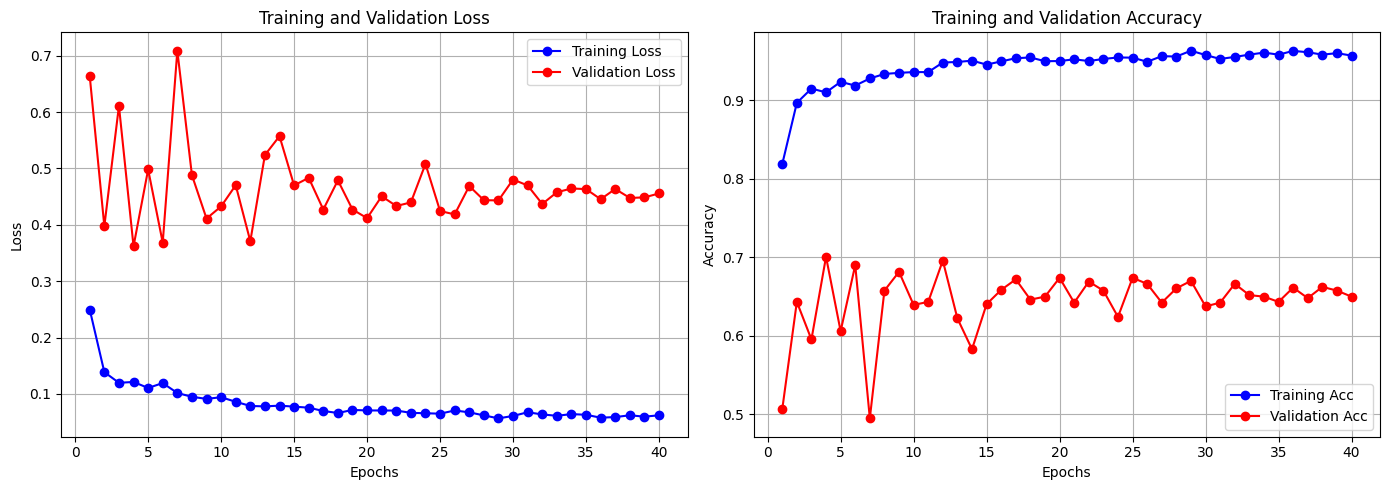

In [9]:
import torch
import matplotlib.pyplot as plt
import os

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(14, 5))

    # 1. Biểu đồ Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-o', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. Biểu đồ Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, 'b-o', label='Training Acc')
    plt.plot(epochs, val_accs, 'r-o', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

try:
    # 1. Đồng bộ hóa với mô hình tốt nhất đã lưu
    if os.path.exists(SAVE_PATH):
        print(f"🔄 Đang tải mô hình tối ưu: {SAVE_PATH}")
        model.load_state_dict(torch.load(SAVE_PATH, map_location=device))

    # 2. Lấy dữ liệu thực tế từ biến history đã được cập nhật ở Bước 3
    # Chúng ta sử dụng dữ liệu thật thay vì dữ liệu mô phỏng (mock data)
    t_loss = history['train_loss']
    v_loss = history['val_loss']
    t_acc = history['train_acc']
    v_acc = history['val_acc']

    if len(t_loss) > 0:
        print(f"📈 Hiển thị biểu đồ thực tế từ {len(t_loss)} epochs đã huấn luyện.")
        plot_training_history(t_loss, v_loss, t_acc, v_acc)
    else:
        print("⚠️ Biến 'history' trống. Vui lòng chạy lại cell huấn luyện (Bước 3).")

except NameError as e:
    print(f"❌ LỖI: Thiếu biến cấu hình ({e}). Hãy chạy cell Bước 3 trước.")
except Exception as e:
    print(f"❌ Đã xảy ra lỗi: {e}")